# Aggregate Fold Results

This notebook aggregates evaluation metrics across all folds from the mds_fpkm_variance_zscore_2000_latent32 run.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
# Define the run directory
run_dir = Path('../workflows/runs/mds_fpkm_variance_zscore_2000_latent32')

# Collect all eval.csv files
all_results = []

for fold_idx in range(10):
    eval_file = run_dir / f'fold_{fold_idx}' / 'eval' / 'eval.csv'
    if eval_file.exists():
        df = pd.read_csv(eval_file)
        df['fold'] = fold_idx
        all_results.append(df)
    else:
        print(f"Warning: {eval_file} not found")

# Combine all results
results_df = pd.concat(all_results, ignore_index=True)
print(f"Loaded results from {len(all_results)} folds")
print(f"Total rows: {len(results_df)}")
results_df.head()


Loaded results from 10 folds
Total rows: 20


,model,r2_train,r2_val,r2_test,mse_train,mse_val,mse_test,path,fold
0,vae,0.917854,0.788355,0.811196,0.082001,0.159366,0.209067,../runs/mds_fpkm_variance_zscore_2000_latent32...,0
1,pca,0.828471,0.781335,0.807517,0.171228,0.164652,0.213141,../runs/mds_fpkm_variance_zscore_2000_latent32...,0
2,vae,0.915395,0.800828,0.791508,0.084456,0.171152,0.186548,../runs/mds_fpkm_variance_zscore_2000_latent32...,1
3,pca,0.831700,0.797379,0.784535,0.168004,0.174116,0.192787,../runs/mds_fpkm_variance_zscore_2000_latent32...,1
4,vae,0.918314,0.794318,0.784838,0.081542,0.202575,0.231650,../runs/mds_fpkm_variance_zscore_2000_latent32...,2


## Summary Statistics

Calculate mean and standard deviation for validation and test metrics across folds.


In [3]:
# Group by model and calculate statistics
summary = results_df.groupby('model').agg({
    'r2_train': ['mean', 'std'],
    'r2_val': ['mean', 'std'],
    'r2_test': ['mean', 'std'],
    'mse_train': ['mean', 'std'],
    'mse_val': ['mean', 'std'],
    'mse_test': ['mean', 'std']
})

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.round(4)
print("\n=== Performance Summary Across All Folds ===")
summary



=== Performance Summary Across All Folds ===


,r2_train_mean,r2_train_std,r2_val_mean,r2_val_std,r2_test_mean,r2_test_std,mse_train_mean,mse_train_std,mse_val_mean,mse_val_std,mse_test_mean,mse_test_std
model,,,,,,,,,,,,
pca,0.8286,0.0039,0.7878,0.0206,0.7944,0.0111,0.1711,0.0039,0.2006,0.0214,0.2005,0.0143
vae,0.9124,0.0080,0.7925,0.0194,0.7964,0.0101,0.0874,0.0080,0.1962,0.0218,0.1988,0.0165


In [6]:
summary[['r2_train_mean', 'r2_val_mean', 'r2_test_mean', 'mse_train_mean', 'mse_val_mean', 'mse_test_mean']].reset_index().style.hide()

model,r2_train_mean,r2_val_mean,r2_test_mean,mse_train_mean,mse_val_mean,mse_test_mean
pca,0.828600,0.787800,0.794400,0.171100,0.200600,0.200500
vae,0.912400,0.792500,0.796400,0.087400,0.196200,0.198800


In [9]:
# Create a formatted display with mean ± std
formatted_summary = pd.DataFrame()

for model in results_df['model'].unique():
    model_data = results_df[results_df['model'] == model]
    
    formatted_summary.loc[model, 'R² Train'] = f"{model_data['r2_train'].mean():.4f} ± {model_data['r2_train'].std():.4f}"
    formatted_summary.loc[model, 'R² Val'] = f"{model_data['r2_val'].mean():.4f} ± {model_data['r2_val'].std():.4f}"
    formatted_summary.loc[model, 'R² Test'] = f"{model_data['r2_test'].mean():.4f} ± {model_data['r2_test'].std():.4f}"
    formatted_summary.loc[model, 'MSE Train'] = f"{model_data['mse_train'].mean():.4f} ± {model_data['mse_train'].std():.4f}"
    formatted_summary.loc[model, 'MSE Val'] = f"{model_data['mse_val'].mean():.4f} ± {model_data['mse_val'].std():.4f}"
    formatted_summary.loc[model, 'MSE Test'] = f"{model_data['mse_test'].mean():.4f} ± {model_data['mse_test'].std():.4f}"
    formatted_summary.loc[model, 'N Folds'] = len(model_data)

print("\n=== Formatted Summary (Mean ± Std) ===")
formatted_summary



=== Formatted Summary (Mean ± Std) ===


,R² Train,R² Val,R² Test,MSE Train,MSE Val,MSE Test,N Folds
vae,0.9124 ± 0.0080,0.7925 ± 0.0194,0.7964 ± 0.0101,0.0874 ± 0.0080,0.1962 ± 0.0218,0.1988 ± 0.0165,10.0
pca,0.8286 ± 0.0039,0.7878 ± 0.0206,0.7944 ± 0.0111,0.1711 ± 0.0039,0.2006 ± 0.0214,0.2005 ± 0.0143,10.0


## Validation and Test Performance


In [10]:
# Focus on val and test metrics
val_test_summary = pd.DataFrame()

for model in results_df['model'].unique():
    model_data = results_df[results_df['model'] == model]
    
    val_test_summary.loc[model, 'R² Val (mean)'] = model_data['r2_val'].mean()
    val_test_summary.loc[model, 'R² Val (std)'] = model_data['r2_val'].std()
    val_test_summary.loc[model, 'R² Test (mean)'] = model_data['r2_test'].mean()
    val_test_summary.loc[model, 'R² Test (std)'] = model_data['r2_test'].std()
    val_test_summary.loc[model, 'MSE Val (mean)'] = model_data['mse_val'].mean()
    val_test_summary.loc[model, 'MSE Val (std)'] = model_data['mse_val'].std()
    val_test_summary.loc[model, 'MSE Test (mean)'] = model_data['mse_test'].mean()
    val_test_summary.loc[model, 'MSE Test (std)'] = model_data['mse_test'].std()

print("\n=== Validation and Test Performance ===")
val_test_summary.round(4)



=== Validation and Test Performance ===


,R² Val (mean),R² Val (std),R² Test (mean),R² Test (std),MSE Val (mean),MSE Val (std),MSE Test (mean),MSE Test (std)
vae,0.7925,0.0194,0.7964,0.0101,0.1962,0.0218,0.1988,0.0165
pca,0.7878,0.0206,0.7944,0.0111,0.2006,0.0214,0.2005,0.0143


## Visualizations


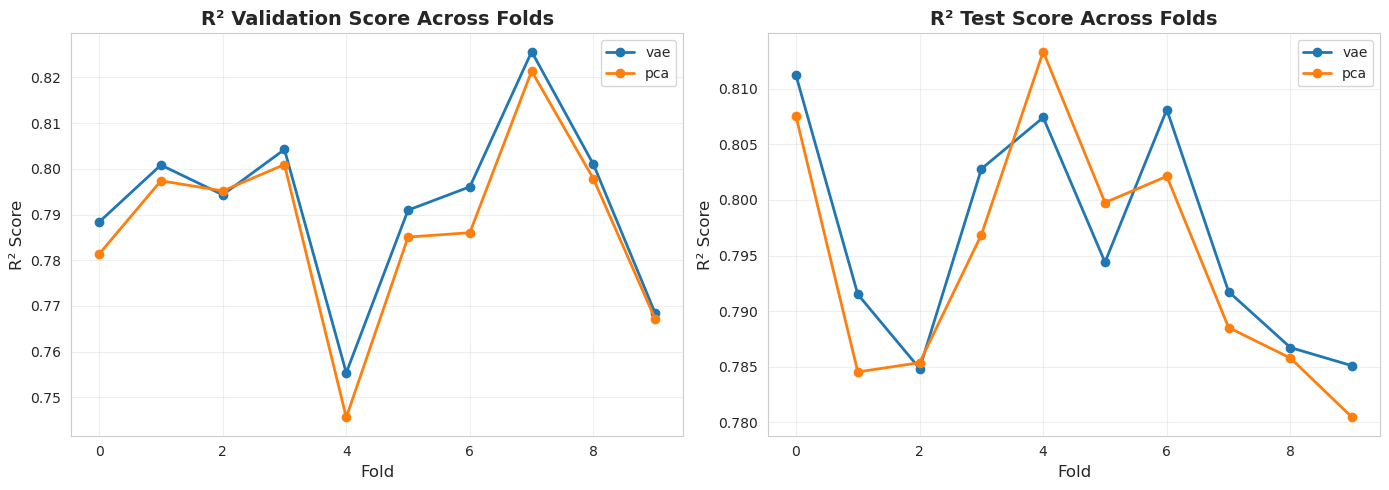

In [11]:
# Plot R² scores across folds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Val
for model in results_df['model'].unique():
    model_data = results_df[results_df['model'] == model]
    axes[0].plot(model_data['fold'], model_data['r2_val'], marker='o', label=model, linewidth=2)
axes[0].set_xlabel('Fold', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² Validation Score Across Folds', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# R² Test
for model in results_df['model'].unique():
    model_data = results_df[results_df['model'] == model]
    axes[1].plot(model_data['fold'], model_data['r2_test'], marker='o', label=model, linewidth=2)
axes[1].set_xlabel('Fold', fontsize=12)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('R² Test Score Across Folds', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


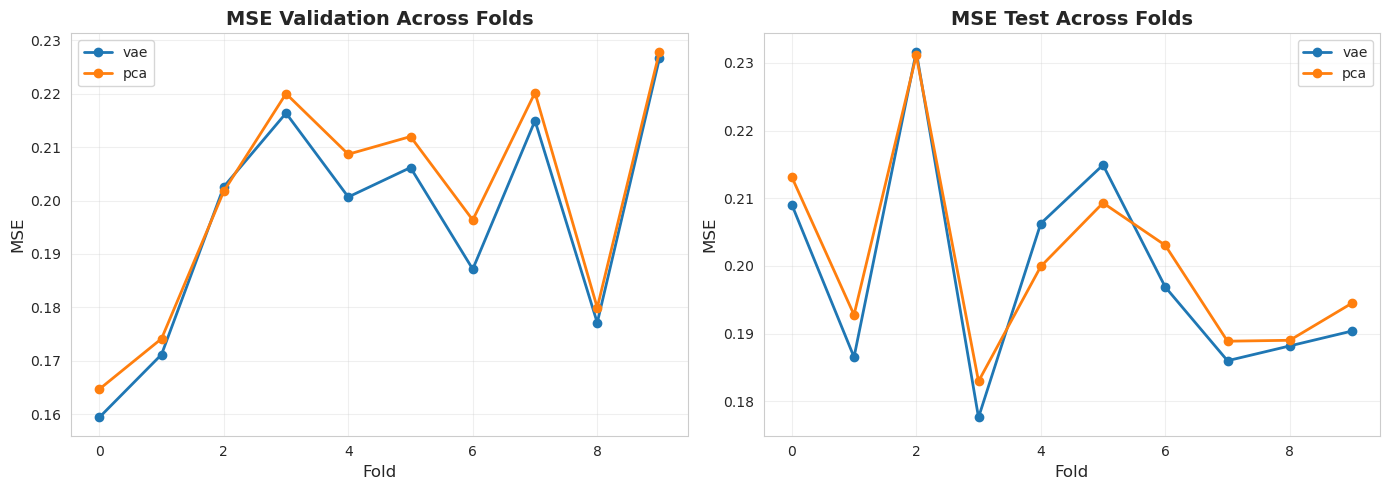

In [12]:
# Plot MSE across folds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE Val
for model in results_df['model'].unique():
    model_data = results_df[results_df['model'] == model]
    axes[0].plot(model_data['fold'], model_data['mse_val'], marker='o', label=model, linewidth=2)
axes[0].set_xlabel('Fold', fontsize=12)
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('MSE Validation Across Folds', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MSE Test
for model in results_df['model'].unique():
    model_data = results_df[results_df['model'] == model]
    axes[1].plot(model_data['fold'], model_data['mse_test'], marker='o', label=model, linewidth=2)
axes[1].set_xlabel('Fold', fontsize=12)
axes[1].set_ylabel('MSE', fontsize=12)
axes[1].set_title('MSE Test Across Folds', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


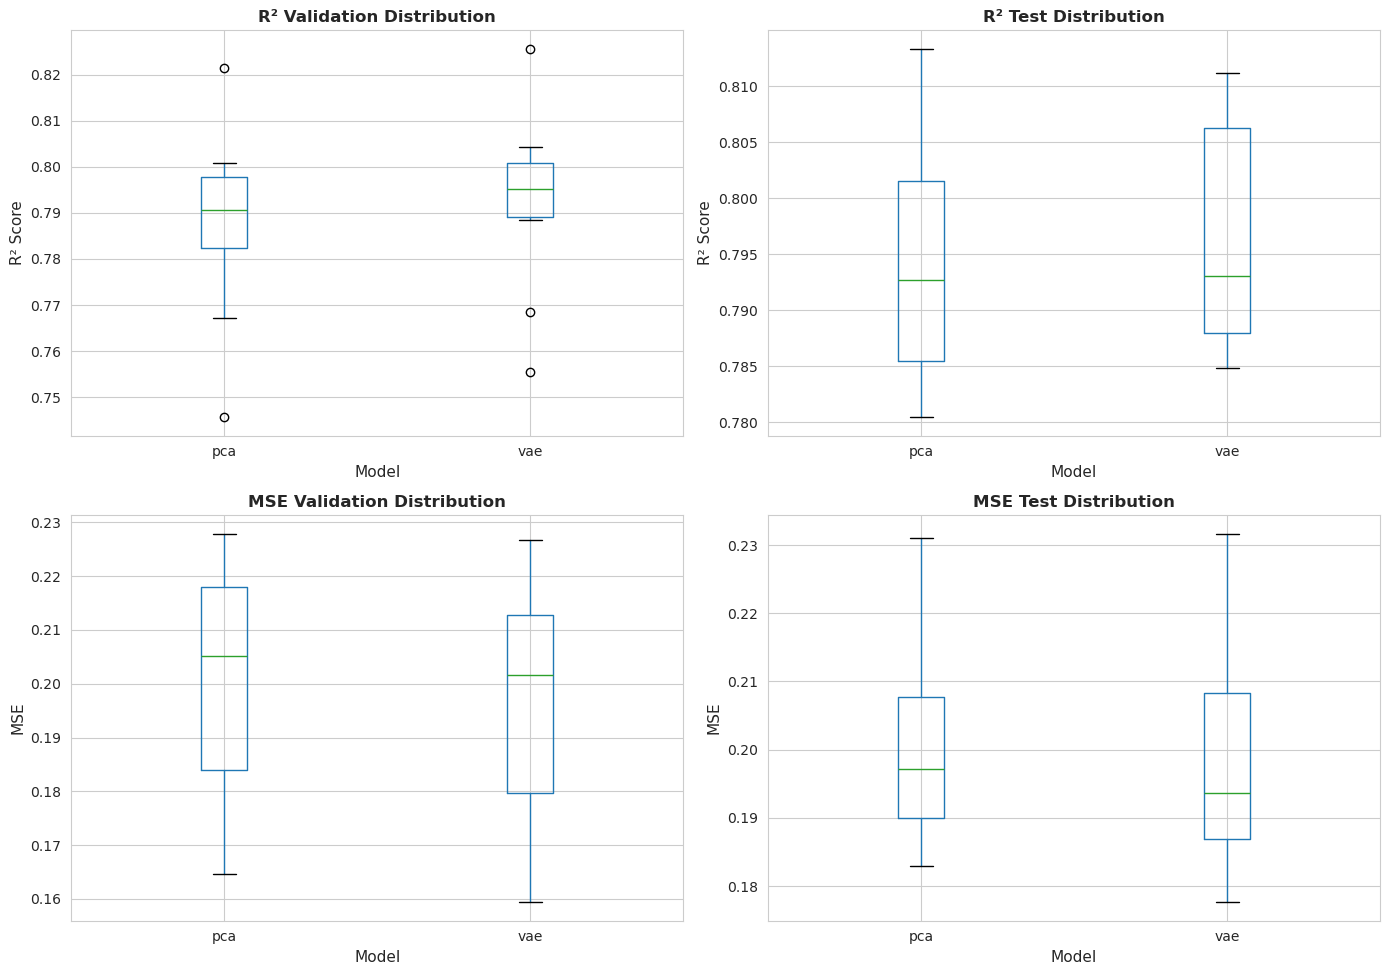

In [13]:
# Box plots for distribution of metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# R² Val
results_df.boxplot(column='r2_val', by='model', ax=axes[0, 0])
axes[0, 0].set_title('R² Validation Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Model', fontsize=11)
axes[0, 0].set_ylabel('R² Score', fontsize=11)
plt.sca(axes[0, 0])
plt.xticks(rotation=0)

# R² Test
results_df.boxplot(column='r2_test', by='model', ax=axes[0, 1])
axes[0, 1].set_title('R² Test Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Model', fontsize=11)
axes[0, 1].set_ylabel('R² Score', fontsize=11)
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# MSE Val
results_df.boxplot(column='mse_val', by='model', ax=axes[1, 0])
axes[1, 0].set_title('MSE Validation Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Model', fontsize=11)
axes[1, 0].set_ylabel('MSE', fontsize=11)
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

# MSE Test
results_df.boxplot(column='mse_test', by='model', ax=axes[1, 1])
axes[1, 1].set_title('MSE Test Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Model', fontsize=11)
axes[1, 1].set_ylabel('MSE', fontsize=11)
plt.sca(axes[1, 1])
plt.xticks(rotation=0)

# Remove the automatic title from boxplot
for ax in axes.flat:
    ax.get_figure().suptitle('')

plt.tight_layout()
plt.show()


## Save Aggregated Results


In [ ]:
# Save the summary statistics
output_dir = run_dir / 'aggregated_results'
output_dir.mkdir(exist_ok=True)

# Save full results
results_df.to_csv(output_dir / 'all_folds_results.csv', index=False)
print(f"Saved all folds results to {output_dir / 'all_folds_results.csv'}")

# Save summary
summary.to_csv(output_dir / 'summary_statistics.csv')
print(f"Saved summary statistics to {output_dir / 'summary_statistics.csv'}")

# Save formatted summary
formatted_summary.to_csv(output_dir / 'formatted_summary.csv')
print(f"Saved formatted summary to {output_dir / 'formatted_summary.csv'}")

# Save val/test summary
val_test_summary.to_csv(output_dir / 'val_test_summary.csv')
print(f"Saved val/test summary to {output_dir / 'val_test_summary.csv'}")


## Individual Fold Details


In [ ]:
# Display full results table
print("\n=== Complete Results for All Folds ===")
display_cols = ['fold', 'model', 'r2_train', 'r2_val', 'r2_test', 'mse_train', 'mse_val', 'mse_test']
results_df[display_cols].sort_values(['model', 'fold'])
